# RT-DETR - Comparación labels reales vs predicción imagen completa (sin inferencia)

Objetivo: predecir sobre las 10 imágenes completas de test, y comparar con los kanjis reales para justificar la necesidad de inferencia con parches.

In [1]:
from pathlib import Path

# Rutas original
ruta_test_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/images/test")
ruta_labels_original = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_original/labels/test")
ruta_modelo_rtdetr_original = "/home/salvarado/TFM/resultados/result_RT_DTR/parches_original_1024_50ep_RT_DTR/weights/best.pt"


# Rutas denoised
ruta_test_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/images/test")
ruta_labels_denoised = Path("/home/salvarado/TFM/Dataset_preparados/dataset_kanji_prep/dataset_denoised/labels/test")
ruta_modelo_rtdetr_denoised = "/home/salvarado/TFM/resultados/result_RT_DTR/parches_denoised_1024_50ep_RT_DTR/weights/best.pt"

print("Rutas definidas")

Rutas definidas


In [2]:
print("Original:")
print(" imágenes:", ruta_test_original.exists())
print(" labels:", ruta_labels_original.exists())

print("Denoised:")
print(" imágenes:", ruta_test_denoised.exists())
print(" labels:", ruta_labels_denoised.exists())

Original:
 imágenes: True
 labels: True
Denoised:
 imágenes: True
 labels: True


## 1. Conteo de kanjis reales (imágenes completas de test - original)

Se cuenta el número de kanjis reales en cada una de las 10 imágenes completas de test,
a partir de los archivos de labels en formato YOLO.

In [3]:
import os

print("Kanjis reales por imagen (original):")
print()
for nombre in sorted(os.listdir(ruta_labels_original)):
    if not nombre.endswith(".txt"):
        continue
    with open(ruta_labels_original / nombre, "r") as f:
        lines = f.readlines()
    print(f"{nombre.replace('.txt', '')}: {len(lines)} kanjis")

Kanjis reales por imagen (original):

sakuma-0447_Page_02: 152 kanjis
sakuma-0451_Page_26: 323 kanjis
sakuma-0469_Page_09: 259 kanjis
sakuma-0469_Page_13: 229 kanjis
sakuma-0470_Page_07: 260 kanjis
sakuma-0513_Page_03: 100 kanjis
sakuma-0513_Page_06: 321 kanjis
sakuma-0581_Page_12: 237 kanjis
sakuma-0581_Page_19: 250 kanjis
sakuma-0581_Page_29: 129 kanjis


In [4]:
def calcular_iou(caja1, caja2):
    """Calcula el IoU entre dos cajas [x1, y1, x2, y2]."""
    x1 = max(caja1[0], caja2[0])
    y1 = max(caja1[1], caja2[1])
    x2 = min(caja1[2], caja2[2])
    y2 = min(caja1[3], caja2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    interseccion = inter_w * inter_h

    area1 = (caja1[2] - caja1[0]) * (caja1[3] - caja1[1])
    area2 = (caja2[2] - caja2[0]) * (caja2[3] - caja2[1])
    union = area1 + area2 - interseccion

    return interseccion / union if union > 0 else 0


def evaluar_deteccion(reales, detectadas, umbral_iou=0.5):
    """
    Empareja detecciones con cajas reales por IoU.
    reales, detectadas: listas de [x1, y1, x2, y2]
    Devuelve: TP, FP, FN
    """
    reales_usadas = [False] * len(reales)
    tp = 0
    fp = 0

    for caja_det in detectadas:
        mejor_iou = 0
        mejor_idx = -1
        for i, caja_real in enumerate(reales):
            if reales_usadas[i]:
                continue
            iou = calcular_iou(caja_det, caja_real)
            if iou > mejor_iou:
                mejor_iou = iou
                mejor_idx = i

        if mejor_iou >= umbral_iou:
            tp += 1
            reales_usadas[mejor_idx] = True
        else:
            fp += 1

    fn = reales_usadas.count(False)
    return tp, fp, fn

print("Funciones de evaluación por IoU cargadas")

Funciones de evaluación por IoU cargadas


## 2. Predicción RT-DETR sobre imágenes completas original (sin inferencia)

In [5]:
from ultralytics import YOLO
import os
import cv2

model_rtdetr_original = YOLO(ruta_modelo_rtdetr_original)

print("Evaluación por IoU - RT-DETR sobre imágenes completas:")
print()

resultados_tabla_rtdetr = []

for nombre in sorted(os.listdir(ruta_test_original)):
    if not nombre.endswith(".png"):
        continue

    img_path = str(ruta_test_original / nombre)
    label_path = str(ruta_labels_original / nombre.replace(".png", ".txt"))

    # Cargar cajas reales (convertir de formato YOLO normalizado a xyxy en píxeles)
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])

    # Predecir
    results = model_rtdetr_original.predict(source=img_path, conf=0.5, imgsz=1024, device=1, verbose=False)
    detectadas = [box.xyxy[0].cpu().numpy().tolist() for box in results[0].boxes]

    # Evaluar por IoU
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    nombre_limpio = nombre.replace(".png", "")
    resultados_tabla_rtdetr.append([nombre_limpio, len(reales), tp, fp, fn, round(precision, 3), round(recall, 3)])
    print(f"{nombre_limpio}: TP={tp}, FP={fp}, FN={fn}, Precisión={precision:.3f}, Recall={recall:.3f}")

Evaluación por IoU - RT-DETR sobre imágenes completas:

sakuma-0447_Page_02: TP=89, FP=5, FN=63, Precisión=0.947, Recall=0.586
sakuma-0451_Page_26: TP=240, FP=21, FN=83, Precisión=0.920, Recall=0.743
sakuma-0469_Page_09: TP=118, FP=15, FN=141, Precisión=0.887, Recall=0.456
sakuma-0469_Page_13: TP=90, FP=14, FN=139, Precisión=0.865, Recall=0.393
sakuma-0470_Page_07: TP=205, FP=18, FN=55, Precisión=0.919, Recall=0.788
sakuma-0513_Page_03: TP=77, FP=2, FN=23, Precisión=0.975, Recall=0.770
sakuma-0513_Page_06: TP=166, FP=36, FN=155, Precisión=0.822, Recall=0.517
sakuma-0581_Page_12: TP=112, FP=12, FN=125, Precisión=0.903, Recall=0.473
sakuma-0581_Page_19: TP=154, FP=28, FN=96, Precisión=0.846, Recall=0.616
sakuma-0581_Page_29: TP=80, FP=8, FN=49, Precisión=0.909, Recall=0.620


### Análisis

Al igual que ocurrió con YOLO, el modelo RT-DETR entrenado con parches no es capaz de detectar correctamente los kanjis cuando se le pasa la imagen completa directamente, sin aplicar el pipeline de inferencia con parches. La precisión se mantiene razonablemente alta (entre 0,822 y 0,975), pero el recall cae de forma notable en varias páginas, llegando hasta 0,393 en sakuma-0469_Page_13, frente a un rango de 0,624-0,940 obtenido por YOLO en las mismas condiciones. Esto indica que, aunque las detecciones que realiza RT-DETR suelen ser correctas, el modelo deja sin detectar una proporción muy superior de kanjis reales en comparación con YOLO.

Esto se debe a que el modelo fue entrenado con parches de 2048px reducidos a 1024px, donde los kanjis se ven a un tamaño suficiente para ser detectados. Al pasarle la imagen completa (~10000px) reducida a 1024px, los kanjis quedan extremadamente pequeños, mucho más de lo visto durante el entrenamiento.

Estos resultados confirman, de forma aún más clara que con YOLO, que es imprescindible aplicar el pipeline de inferencia con parches para obtener detecciones fiables con RT-DETR sobre imágenes completas.


## 3. Visualización predicción sobre imagen completa original

Se visualiza una imagen de test para ver cómo predice  el modelo directamente sobre la imagen completa

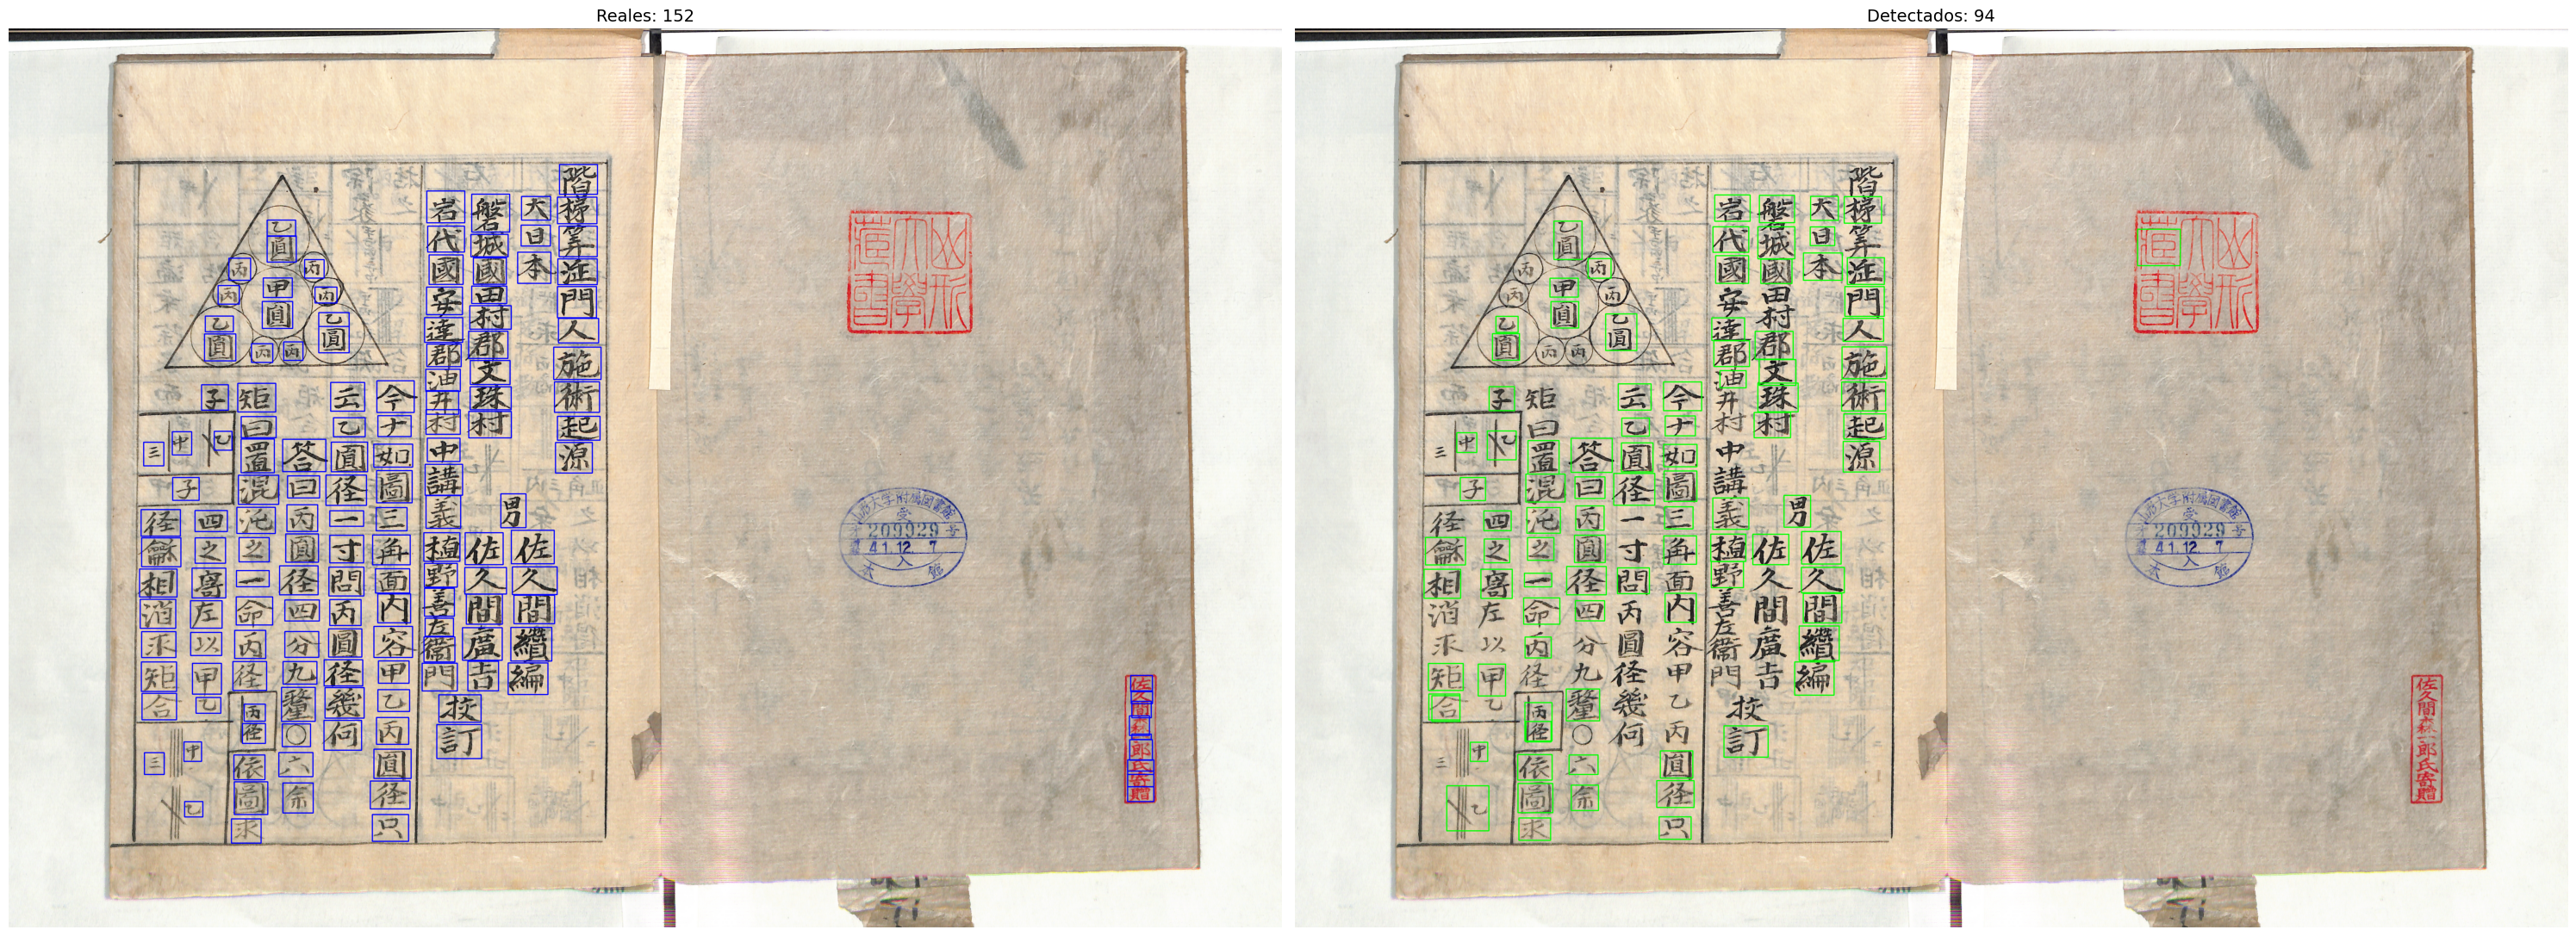

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import glob
import os

# Solo la primera imagen
img_path = sorted(glob.glob(str(ruta_test_original) + "/*.png"))[0]
imagen = cv2.imread(img_path)
nombre = os.path.basename(img_path).replace(".png","")

# Leer reales
label_path = str(ruta_labels_original / (nombre + ".txt"))
reales = []
with open(label_path) as f:
    for linea in f:
        datos = linea.split()
        alto, ancho = imagen.shape[:2]
        cx = float(datos[1]) * ancho
        cy = float(datos[2]) * alto
        bw = float(datos[3]) * ancho
        bh = float(datos[4]) * alto
        reales.append([int(cx-bw/2), int(cy-bh/2), int(cx+bw/2), int(cy+bh/2)])

# Predecir sobre imagen completa
results = model_rtdetr_original.predict(source=img_path, conf=0.5, imgsz=1024, device=1, verbose=False)

# Dibujar reales (azul) y detectados (verde)
img_reales = imagen.copy()
for x1,y1,x2,y2 in reales:
    cv2.rectangle(img_reales, (x1,y1), (x2,y2), (255,0,0), 8)

img_detect = imagen.copy()
for box in results[0].boxes:
    x1,y1,x2,y2 = box.xyxy[0].cpu().numpy().astype(int)
    cv2.rectangle(img_detect, (x1,y1), (x2,y2), (0,255,0), 8)

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
axes[0].imshow(cv2.cvtColor(img_reales, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Reales: {len(reales)}", fontsize=14)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_detect, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detectados: {len(results[0].boxes)}", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Análisis visual

La imagen sakuma-0447_Page_02 contiene 152 kanjis reales (marcados en azul), de los cuales el modelo RT-DETR, al aplicarse sobre la imagen completa , solo detecta 
94 (marcados en verde), Se observa que un número considerable de kanjis quedan sin detectar, especialmente aquellos de menor tamaño o ubicados en zonas con mayor densidad de caracteres. Esto refuerza la necesidad de aplicar el pipeline de inferencia con parches también para RT-DETR.

---
# Denoised

## Predicción RT-DETR sobre imágenes completas (sin inferencia) - Denoised


## 1. Conteo de kanjis reales (imágenes completas de test - denoised)

In [3]:
import os

print("Kanjis reales por imagen (denoised):")
print()
for nombre in sorted(os.listdir(ruta_labels_denoised)):
    if not nombre.endswith(".txt"):
        continue
    with open(ruta_labels_denoised / nombre, "r") as f:
        lines = f.readlines()
    print(f"{nombre.replace('.txt', '')}: {len(lines)} kanjis")

Kanjis reales por imagen (denoised):

sakuma-0447_Page_02denoised: 152 kanjis
sakuma-0451_Page_26denoised: 323 kanjis
sakuma-0469_Page_09denoised: 259 kanjis
sakuma-0469_Page_13denoised: 229 kanjis
sakuma-0470_Page_07denoised: 260 kanjis
sakuma-0513_Page_03denoised: 100 kanjis
sakuma-0513_Page_06denoised: 321 kanjis
sakuma-0581_Page_12denoised: 237 kanjis
sakuma-0581_Page_19denoised: 250 kanjis
sakuma-0581_Page_29denoised: 129 kanjis


## 2. Predicción RT-DETR sobre imágenes completas (sin pipeline) - Denoised

In [6]:
from ultralytics import YOLO
import os
import cv2

model_rtdetr_denoised = YOLO(ruta_modelo_rtdetr_denoised)

print("Evaluación por IoU - RT-DETR sobre imágenes completas (denoised, sin pipeline):")
print()

resultados_tabla_rtdetr_denoised = []

for nombre in sorted(os.listdir(ruta_test_denoised)):
    if not nombre.endswith(".png"):
        continue

    img_path = str(ruta_test_denoised / nombre)
    label_path = str(ruta_labels_denoised / nombre.replace(".png", ".txt"))

    # Cargar cajas reales
    imagen = cv2.imread(img_path)
    alto, ancho = imagen.shape[:2]
    reales = []
    with open(label_path) as f:
        for linea in f:
            datos = linea.split()
            cx = float(datos[1]) * ancho
            cy = float(datos[2]) * alto
            bw = float(datos[3]) * ancho
            bh = float(datos[4]) * alto
            reales.append([cx - bw/2, cy - bh/2, cx + bw/2, cy + bh/2])

    # Predecir
    results = model_rtdetr_denoised.predict(source=img_path, conf=0.5, imgsz=1024, device=1, verbose=False)
    detectadas = [box.xyxy[0].cpu().numpy().tolist() for box in results[0].boxes]

    # Evaluar por IoU
    tp, fp, fn = evaluar_deteccion(reales, detectadas, umbral_iou=0.5)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    nombre_limpio = nombre.replace(".png", "")
    resultados_tabla_rtdetr_denoised.append([nombre_limpio, len(reales), tp, fp, fn, round(precision, 3), round(recall, 3)])
    print(f"{nombre_limpio}: TP={tp}, FP={fp}, FN={fn}, Precisión={precision:.3f}, Recall={recall:.3f}")

Evaluación por IoU - RT-DETR sobre imágenes completas (denoised, sin pipeline):

sakuma-0447_Page_02denoised: TP=71, FP=1, FN=81, Precisión=0.986, Recall=0.467
sakuma-0451_Page_26denoised: TP=103, FP=2, FN=220, Precisión=0.981, Recall=0.319
sakuma-0469_Page_09denoised: TP=82, FP=4, FN=177, Precisión=0.953, Recall=0.317
sakuma-0469_Page_13denoised: TP=67, FP=2, FN=162, Precisión=0.971, Recall=0.293
sakuma-0470_Page_07denoised: TP=104, FP=3, FN=156, Precisión=0.972, Recall=0.400
sakuma-0513_Page_03denoised: TP=65, FP=0, FN=35, Precisión=1.000, Recall=0.650
sakuma-0513_Page_06denoised: TP=72, FP=9, FN=249, Precisión=0.889, Recall=0.224
sakuma-0581_Page_12denoised: TP=53, FP=1, FN=184, Precisión=0.981, Recall=0.224
sakuma-0581_Page_19denoised: TP=79, FP=4, FN=171, Precisión=0.952, Recall=0.316
sakuma-0581_Page_29denoised: TP=55, FP=2, FN=74, Precisión=0.965, Recall=0.426


## 3. Visualización predicción sobre imagen completa (sin pipeline) - Denoised

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import cv2
import glob
import os

# Solo la primera imagen
img_path = sorted(glob.glob(str(ruta_test_denoised) + "/*.png"))[0]
imagen = cv2.imread(img_path)
nombre = os.path.basename(img_path).replace(".png","")

# Leer reales
label_path = str(ruta_labels_denoised / (nombre + ".txt"))
reales = []
with open(label_path) as f:
    for linea in f:
        datos = linea.split()
        alto, ancho = imagen.shape[:2]
        cx = float(datos[1]) * ancho
        cy = float(datos[2]) * alto
        bw = float(datos[3]) * ancho
        bh = float(datos[4]) * alto
        reales.append([int(cx-bw/2), int(cy-bh/2), int(cx+bw/2), int(cy+bh/2)])

# Predecir sobre imagen completa
results = model_rtdetr_denoised.predict(source=img_path, conf=0.5, imgsz=1024, device=1, verbose=False)

# Dibujar reales (azul) y detectados (verde)
img_reales = imagen.copy()
for x1,y1,x2,y2 in reales:
    cv2.rectangle(img_reales, (x1,y1), (x2,y2), (255,0,0), 8)

img_detect = imagen.copy()
for box in results[0].boxes:
    x1,y1,x2,y2 = box.xyxy[0].cpu().numpy().astype(int)
    cv2.rectangle(img_detect, (x1,y1), (x2,y2), (0,255,0), 8)

fig, axes = plt.subplots(1, 2, figsize=(30, 12))
axes[0].imshow(cv2.cvtColor(img_reales, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Reales: {len(reales)}", fontsize=14)
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(img_detect, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Detectados: {len(results[0].boxes)}", fontsize=14)
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Análisis final: RT-DETR sobre imagen completa (original vs. denoised)

Al comparar ambos datasets sin aplicar el pipeline de parches, se observa que RT-DETR obtiene un recall considerablemente más bajo sobre las imágenes denoised (entre 0,224 y 0,650) que sobre las originales (entre 0,393 y 0,788), pese a mantener una precisión igualmente alta en ambos casos (0,889-1,000 en denoised, 0,822-0,975 en original).

Este resultado es coherente con lo observado en el apartado 6.3 de este trabajo, donde RT-DETR mostraba la mayor caída de rendimiento de las cuatro arquitecturas al aplicar denoising sobre imagen completa (-0,181 puntos de mAP50, la mayor variación registrada en la Tabla 6.3). La evaluación por IoU realizada aquí confirma este mismo patrón a nivel de página individual: RT-DETR es especialmente sensible a la combinación de imagen completa sin pipeline y preprocesamiento por reducción de ruido, mostrando en este escenario su comportamiento más inestable de todas las configuraciones evaluadas en el apartado 6.5.